In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

## Parameters

In [2]:
initial_capital = 1000
risk_free_rate = 0.03
ADX_Period = 14
ADX_Threshold = 25
RSI_Period = 14
RSI_Overbought = 70
RSI_Oversold = 30
use_open_price = False
Day_Per_Year = 365 
Short_Window = 20
Long_Window = 50


start = "2024-10-01"
end = "2025-10-01"
symbols = ["BTC-USD"]
index_symbols = ["^GSPC"]

before starting, in the signals:
- 1 means a buy position
- -1 means a sell position
-  0 means to hold or do nothing

## Data Loading

In [3]:
try:
    df = pd.read_csv('stocks.csv',skiprows=[1,2])
    spx = pd.read_csv('spx.csv',skiprows=[1,2])
except FileNotFoundError:
    df = yf.download(tickers=symbols , start=start , end=end)
    spx = yf.download(tickers=index_symbols , start=start , end=end)
    df.to_csv('stocks.csv')
    spx.to_csv('spx.csv')

In [4]:
df = pd.read_csv("stocks.csv", skiprows=[1,2])
spx = pd.read_csv('spx.csv' , skiprows=[1,2])

In [5]:
df = df.rename(columns={"Price": "Date"})
df["Date"] = pd.to_datetime(df["Date"])
for col in ["Open", "High", "Low", "Close"]:
    df[col] = df[col].astype(float).squeeze()
df

,Date,Close,High,Low,Open,Volume
0,2024-10-01,60837.007812,64110.980469,60189.277344,63335.605469,50220923500
1,2024-10-02,60632.785156,62357.687500,59996.949219,60836.324219,40762722398
2,2024-10-03,60759.402344,61469.039062,59878.804688,60632.484375,36106447279
3,2024-10-04,62067.476562,62465.992188,60459.941406,60754.625000,29585472513
4,2024-10-05,62089.949219,62371.023438,61689.582031,62067.609375,13305410749
...,...,...,...,...,...,...
360,2025-09-26,109712.828125,110359.195312,108728.976562,109041.296875,57738288949
361,2025-09-27,109681.945312,109778.500000,109144.296875,109707.140625,26308042910
362,2025-09-28,112122.640625,112375.484375,109236.945312,109681.945312,33371048505
363,2025-09-29,114400.382812,114473.570312,111589.953125,112117.875000,60000147466


In [6]:
spx = spx.rename(columns={"Price": "Date"})
spx["Date"] = pd.to_datetime(spx["Date"])
for col in ["Open", "High", "Low", "Close"]:
    spx[col] = spx[col].astype(float).squeeze()
spx

,Date,Close,High,Low,Open,Volume
0,2024-10-01,5708.750000,5757.729980,5681.279785,5757.729980,4025180000
1,2024-10-02,5709.540039,5719.629883,5674.000000,5698.140137,3829050000
2,2024-10-03,5699.939941,5718.779785,5677.370117,5698.189941,3597450000
3,2024-10-04,5751.069824,5753.209961,5702.830078,5737.479980,3479400000
4,2024-10-07,5695.939941,5739.339844,5686.850098,5737.799805,3637790000
...,...,...,...,...,...,...
245,2025-09-24,6637.970215,6672.660156,6621.759766,6669.790039,5459180000
246,2025-09-25,6604.720215,6619.000000,6569.220215,6608.189941,5874670000
247,2025-09-26,6643.700195,6648.970215,6604.430176,6615.379883,5103110000
248,2025-09-29,6661.209961,6677.310059,6644.490234,6661.580078,5358760000


## Indicators

In [ ]:
def calculate_adx(df, period=ADX_Period, adx_threshold=ADX_Threshold):
    df['H_diff'] = df['High'] - df['High'].shift(1)
    df['L_diff'] = df['Low'].shift(1) - df['Low']
    
    df['+DM'] = 0.0
    df['-DM'] = 0.0
    
    for i in range(1, len(df)):
        h_diff = df['H_diff'].iloc[i]
        l_diff = df['L_diff'].iloc[i]
        
        if h_diff > l_diff and h_diff > 0:
            df.loc[df.index[i], '+DM'] = h_diff
        elif l_diff > h_diff and l_diff > 0:
            df.loc[df.index[i], '-DM'] = l_diff
    
    # TR
    df['TR1'] = df['High'] - df['Low']
    df['TR2'] = abs(df['High'] - df['Close'].shift(1))
    df['TR3'] = abs(df['Low'] - df['Close'].shift(1))
    df['TR'] = df[['TR1', 'TR2', 'TR3']].max(axis=1)
    
    # ATR
    df['ATR'] = df['TR'].rolling(window=period).mean()
    
    # DM sma
    df['SMA_+DM'] = df['+DM'].rolling(window=period).mean()
    df['SMA_-DM'] = df['-DM'].rolling(window=period).mean()
    
    # DI
    df['+DI'] = (df['SMA_+DM'] / df['ATR']) * 100
    df['-DI'] = (df['SMA_-DM'] / df['ATR']) * 100
    
    # DX
    di_diff = abs(df['+DI'] - df['-DI'])
    di_sum = df['+DI'] + df['-DI']
    
    df['DX'] = np.where(di_sum != 0, (di_diff / di_sum) * 100, 0)
    
    # ADX
    df['ADX'] = df['DX'].rolling(window=period).mean()
    
    df['market_state'] = np.where(df['ADX'] > adx_threshold, 'trending', 'sideways')
    
    return df



In [8]:
def calculate_sma(df, short_window=Short_Window, long_window=Long_Window):
    df['SMA_short'] = df['Close'].rolling(window=short_window).mean()
    df['SMA_long'] = df['Close'].rolling(window=long_window).mean()
    
    df['SMA_diff'] = df['SMA_short'] - df['SMA_long']
    
    return df

In [9]:
def calculate_rsi(df, period=RSI_Period):
    df['price_change'] = df['Close'] - df['Close'].shift(1)
    
    df['gain'] = np.where(df['price_change'] > 0, df['price_change'], 0)
    df['loss'] = np.where(df['price_change'] < 0, abs(df['price_change']), 0)
    
    df['avg_gain'] = df['gain'].rolling(window=period).mean()
    df['avg_loss'] = df['loss'].rolling(window=period).mean()
    
    df['RS'] = df['avg_gain'] / df['avg_loss']
    
    df['RSI'] = 100 - (100 / (1 + df['RS']))
    
    return df


## Signals

In [ ]:
def get_sma_signals(df):
    sma_sig = pd.Series(0, index=df.index)
    sma_sig[df['SMA_short'] > df['SMA_long']] = 1
    sma_sig[df['SMA_short'] < df['SMA_long']] = -1
    
    return sma_sig.tolist()

In [11]:
def get_rsi_mean_reversion_signals(df, oversold=RSI_Oversold , overbought=RSI_Overbought):
    rsi = df['RSI']
    signals = [0] * len(df)
    for i in range(len(df)):
        if pd.notna(rsi.iloc[i]):
            if rsi.iloc[i] < oversold:
                signals[i] = 1
            elif rsi.iloc[i] > overbought:
                signals[i] = -1
            else:
                signals[i] = 0
    return signals

## Backtest

In [ ]:
def apply_strategy_on_df(df):
    calculate_adx(df)
    calculate_sma(df)
    calculate_rsi(df)
    
    sma_signals = get_sma_signals(df)
    rsi_signals = get_rsi_mean_reversion_signals(df)
    
    final_signals = []
    for i in range(len(df)):
        market_state = df['market_state'].iloc[i]
        
        if market_state == 'trending':
            final_signals.append(sma_signals[i])
        elif market_state == 'sideways':
            final_signals.append(rsi_signals[i])
        else:
            final_signals.append(0)
    
    df['signal'] = final_signals
    
    return df

In [13]:
def backtest_strategy(df):
    price_col = 'Open' if use_open_price else 'Close'
    df['returns'] = df[price_col].pct_change().fillna(0)
    
    df['position'] = df['signal'].shift(1).fillna(0)
    
    df['strategy_returns'] = df['position'] * df['returns']
    
    df['cumulative_returns'] = (1 + df['strategy_returns'].fillna(0)).cumprod()
    df['equity'] = df['cumulative_returns'] * initial_capital
    
    return df

In [14]:
apply_strategy_on_df(df)
backtest_strategy(df)

,Date,Close,High,Low,Open,Volume,H_diff,L_diff,+DM,-DM,...,avg_gain,avg_loss,RS,RSI,signal,returns,position,strategy_returns,cumulative_returns,equity
0,2024-10-01,60837.007812,64110.980469,60189.277344,63335.605469,50220923500,NaN,NaN,0.000000,0.000000,...,NaN,NaN,NaN,NaN,0,0.000000,0.0,0.000000,1.000000,1000.000000
1,2024-10-02,60632.785156,62357.687500,59996.949219,60836.324219,40762722398,-1753.292969,192.328125,0.000000,192.328125,...,NaN,NaN,NaN,NaN,0,-0.003357,0.0,-0.000000,1.000000,1000.000000
2,2024-10-03,60759.402344,61469.039062,59878.804688,60632.484375,36106447279,-888.648438,118.144531,0.000000,118.144531,...,NaN,NaN,NaN,NaN,0,0.002088,0.0,0.000000,1.000000,1000.000000
3,2024-10-04,62067.476562,62465.992188,60459.941406,60754.625000,29585472513,996.953125,-581.136719,996.953125,0.000000,...,NaN,NaN,NaN,NaN,0,0.021529,0.0,0.000000,1.000000,1000.000000
4,2024-10-05,62089.949219,62371.023438,61689.582031,62067.609375,13305410749,-94.968750,-1229.640625,0.000000,0.000000,...,NaN,NaN,NaN,NaN,0,0.000362,0.0,0.000000,1.000000,1000.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,2025-09-26,109712.828125,110359.195312,108728.976562,109041.296875,57738288949,-3181.890625,-15.578125,0.000000,0.000000,...,293.928571,750.267857,0.391765,28.148782,-1,0.006085,-1.0,-0.006085,1.333035,1333.034673
361,2025-09-27,109681.945312,109778.500000,109144.296875,109707.140625,26308042910,-580.695312,-415.320312,0.000000,0.000000,...,293.928571,741.683036,0.396299,28.382124,1,-0.000281,-1.0,0.000281,1.333410,1333.409905
362,2025-09-28,112122.640625,112375.484375,109236.945312,109681.945312,33371048505,2596.984375,-92.648438,2596.984375,0.000000,...,468.263951,702.907924,0.666181,39.982513,1,0.022252,1.0,0.022252,1.363082,1363.081583
363,2025-09-29,114400.382812,114473.570312,111589.953125,112117.875000,60000147466,2098.085938,-2353.007812,2098.085938,0.000000,...,628.301339,702.907924,0.893860,47.197789,1,0.020315,1.0,0.020315,1.390772,1390.772230


## Metrics

In [15]:
equity = df['equity']
ret = df['strategy_returns'].dropna()
days = len(ret)

total_return = (equity.iloc[-1] / initial_capital) - 1
cagr = (1 + total_return) ** (Day_Per_Year / days) - 1 if days > 0 else 0
gross_profit = equity.diff().clip(lower=0).sum()
net_profit = equity.iloc[-1] - initial_capital


volatility = ret.std() * np.sqrt(Day_Per_Year)

roll_max = equity.cummax()
drawdown = (equity - roll_max) / roll_max
max_dd = drawdown.min()


is_dd = drawdown < 0
dd_duration = is_dd.groupby((~is_dd).cumsum()).cumsum().max()


rf_daily = (1 + risk_free_rate) ** (1 / Day_Per_Year) - 1
excess_ret = ret - rf_daily
ann_excess = excess_ret.mean() * Day_Per_Year


sharpe = ann_excess / volatility if volatility != 0 else 0


downside_risk = np.sqrt((ret[ret < 0] ** 2).mean()) * np.sqrt(Day_Per_Year)
sortino = ann_excess / downside_risk if downside_risk != 0 else 0


info_ratio = np.nan
spx_ret = spx['Close'].pct_change().reindex(ret.index).dropna()
active_ret = (ret - spx_ret).dropna()
tracking_err = active_ret.std() * np.sqrt(Day_Per_Year)
info_ratio = (active_ret.mean() * Day_Per_Year) / tracking_err if tracking_err != 0 else 0



print(f"{'Metric':<25} | {'Value'}")
print("-" * 40)
print(f"{'Net Profit':<25} | ${net_profit:,.2f}")
print(f"{'Gross Profit':<25} | ${gross_profit:,.2f}")
print(f"{'ROI':<25} | {total_return:.2%}")
print(f"{'Annualized Return (CAGR)':<25} | {cagr:.2%}")
print(f"{'Annualized Volatility':<25} | {volatility:.2%}")
print(f"{'Max Drawdown':<25} | {max_dd:.2%}")
print(f"{'Max DD Duration':<25} | {dd_duration:.0f} Days")
print("-" * 40)
print(f"{'Sharpe Ratio':<25} | {sharpe:.2f}")
print(f"{'Sortino Ratio':<25} | {sortino:.2f}")
print(f"{'Information Ratio':<25} | {info_ratio:.2f}")

Metric                    | Value
----------------------------------------
Net Profit                | $386.59
Gross Profit              | $2,395.54
ROI                       | 38.66%
Annualized Return (CAGR)  | 38.66%
Annualized Volatility     | 34.15%
Max Drawdown              | -16.35%
Max DD Duration           | 69 Days
----------------------------------------
Sharpe Ratio              | 1.04
Sortino Ratio             | 0.93
Information Ratio         | 0.68


## Vizualization

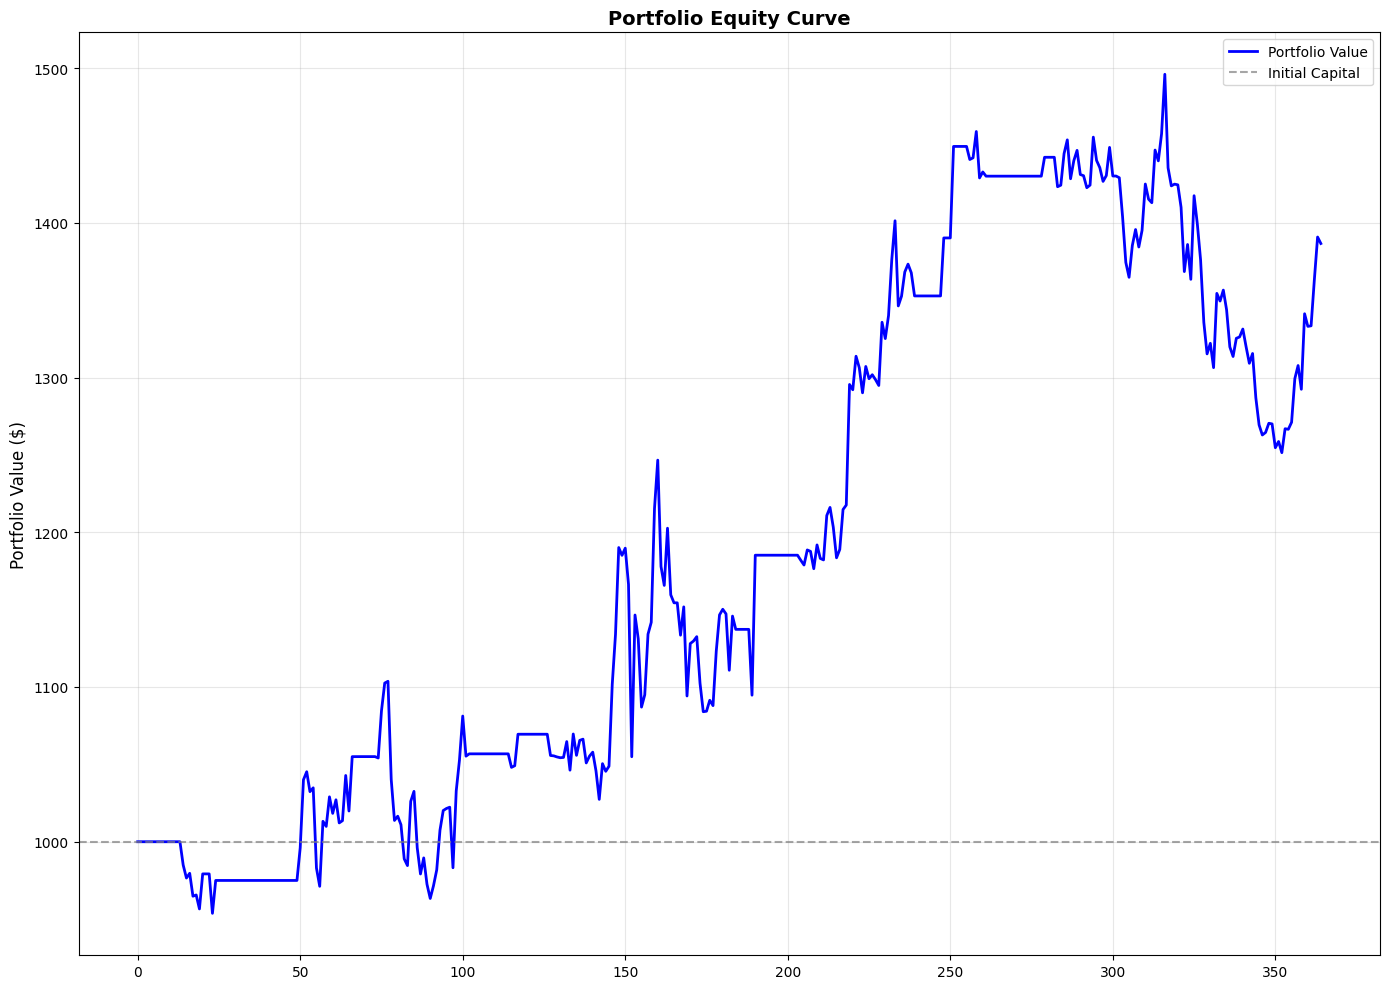

In [16]:
fig, (ax1) = plt.subplots(1, 1, figsize=(14, 10))

ax1.plot(df.index, df['equity'], label='Portfolio Value', linewidth=2, color='blue')
ax1.axhline(y=initial_capital, color='gray', linestyle='--', label='Initial Capital', alpha=0.7)
ax1.set_title('Portfolio Equity Curve', fontsize=14, fontweight='bold')
ax1.set_ylabel('Portfolio Value ($)', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


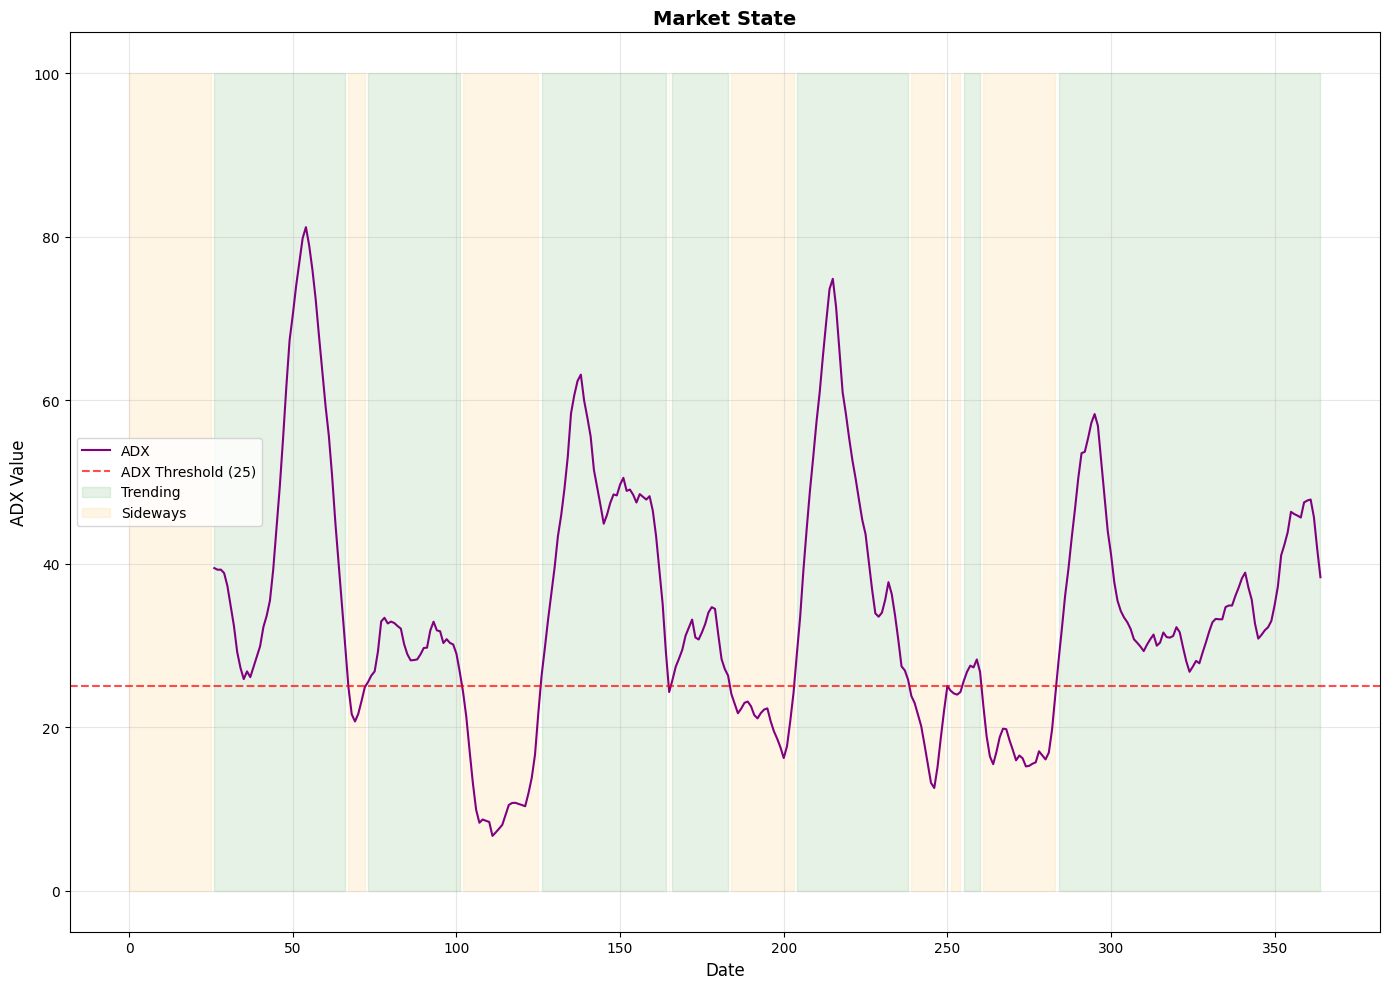

In [17]:
fig, (ax1) = plt.subplots(1, 1, figsize=(14, 10))

ax1.plot(df.index, df['ADX'], label='ADX', linewidth=1.5, color='purple')
ax1.axhline(y=25, color='red', linestyle='--', label='ADX Threshold (25)', alpha=0.7)
ax1.fill_between(df.index, 0, 100, where=df['market_state']=='trending', 
                    alpha=0.1, color='green', label='Trending')
ax1.fill_between(df.index, 0, 100, where=df['market_state']=='sideways', 
                    alpha=0.1, color='orange', label='Sideways')
ax1.set_title('Market State', fontsize=14, fontweight='bold')
ax1.set_ylabel('ADX Value', fontsize=12)
ax1.set_xlabel('Date', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

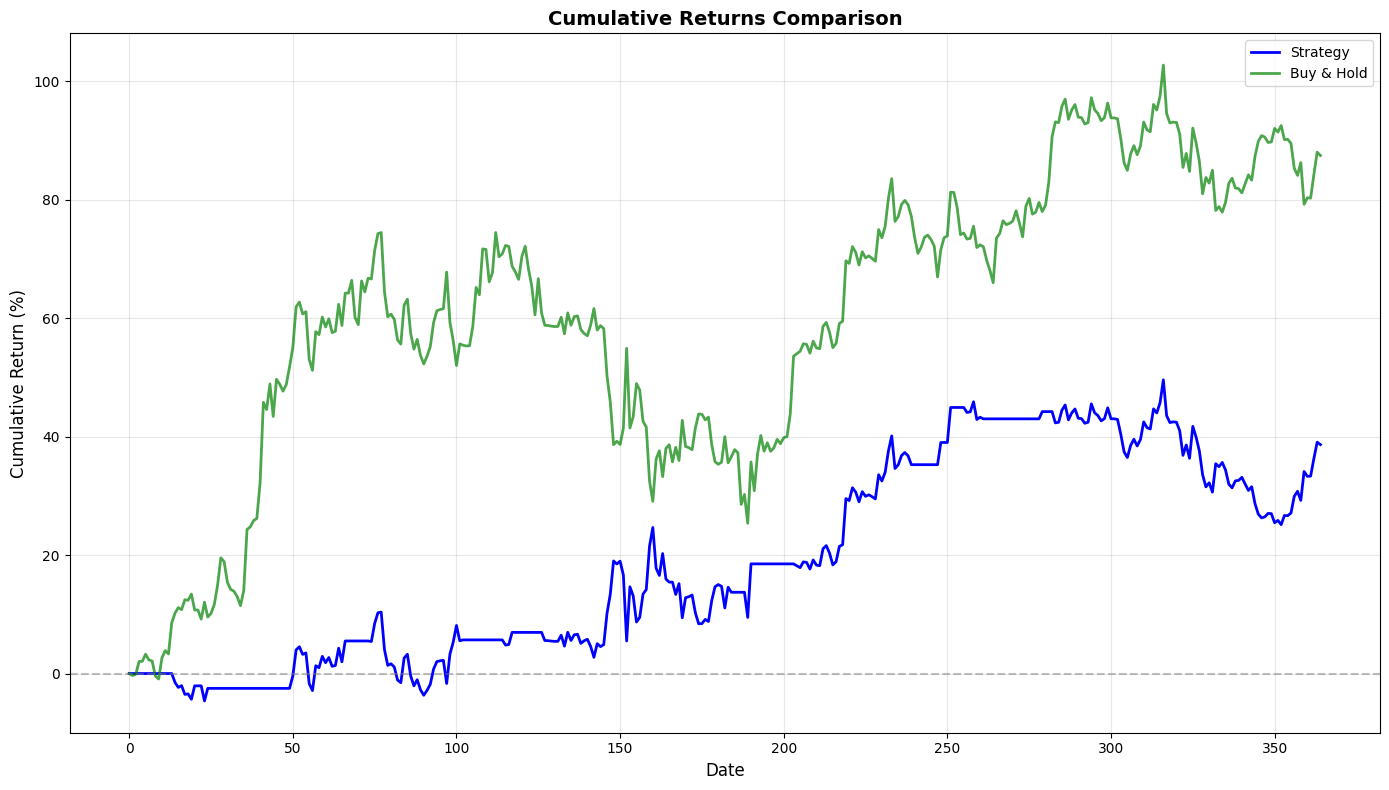

In [19]:
fig, ax = plt.subplots(figsize=(14, 8))
ax.plot(df.index, (df['equity'] / initial_capital - 1) * 100, label='Strategy', linewidth=2, color='blue')

buy_hold_returns = (df['Close'] / df['Close'].iloc[0] - 1) * 100
ax.plot(df.index, buy_hold_returns, label='Buy & Hold', linewidth=2, color='green', alpha=0.7)

ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Cumulative Returns Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Cumulative Return (%)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


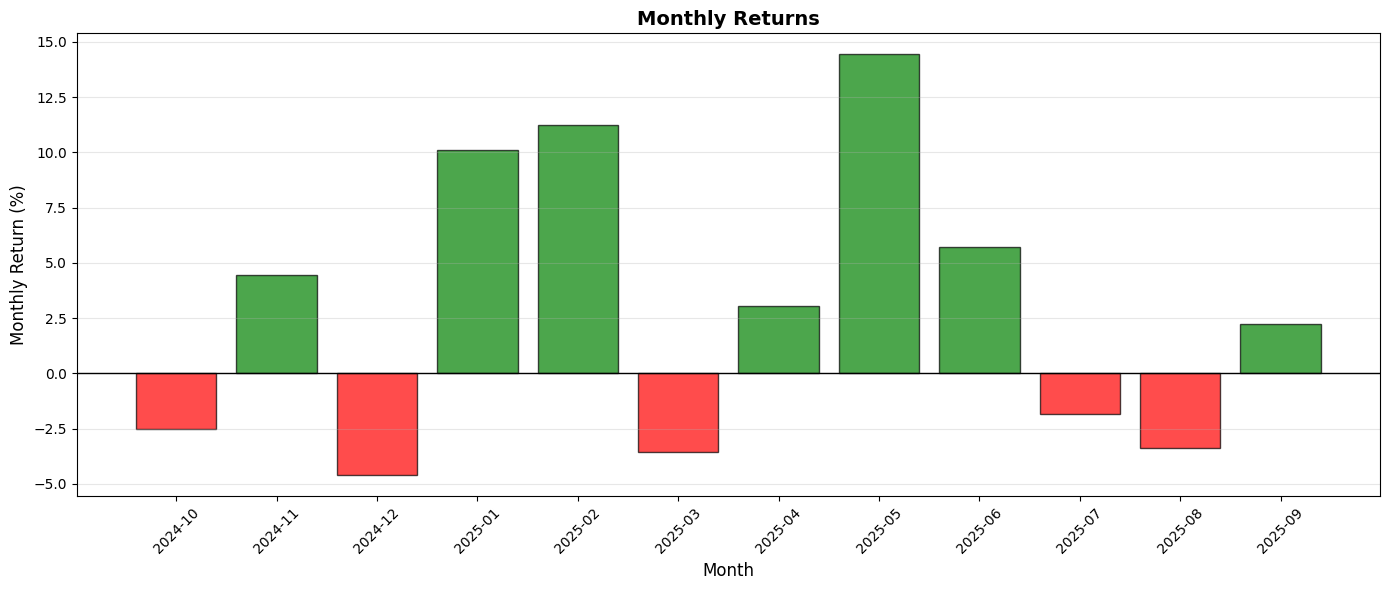

In [21]:
monthly_returns = df.set_index('Date')['strategy_returns'].resample('ME').apply(lambda x: (1 + x).prod() - 1)
monthly_returns_pct = monthly_returns * 100

if len(monthly_returns_pct) > 0:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    colors = ['red' if x < 0 else 'green' for x in monthly_returns_pct]
    ax.bar(range(len(monthly_returns_pct)), monthly_returns_pct, color=colors, alpha=0.7, edgecolor='black')
    ax.axhline(y=0, color='black', linewidth=1)
    ax.set_title('Monthly Returns', fontsize=14, fontweight='bold')
    ax.set_ylabel('Monthly Return (%)', fontsize=12)
    ax.set_xlabel('Month', fontsize=12)
    ax.set_xticks(range(len(monthly_returns_pct)))
    ax.set_xticklabels([d.strftime('%Y-%m') for d in monthly_returns_pct.index], rotation=45)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()